
# DEU GR Experiment 01B — SR Audit Bridge + Native Defect Measurement Harness

This notebook is the bridge from the uploaded `DEU_SR_Fingerprint_Audit.ipynb` into the proposed DEU gravity experiments.

It does four things:

1. Audits the uploaded SR notebook and reports which source files are needed to rerun the old foam engine.
2. Adds graph-shell/circumference instrumentation for the conical-deficit test.
3. Runs a self-contained synthetic calibration of the stair-step measurement pipeline.
4. Produces the exact export schema needed from the real DEU/RMR engine for the next run.

The synthetic calibration is not claimed as evidence that the current DEU engine already produces gravity. It verifies that the measurement harness detects integer shell deficits correctly, so that the next run can test whether persistent defects in the native engine produce the same observable without imposing it by hand.


In [1]:

from __future__ import annotations

import json
import math
import re
import shutil
from collections import deque
from pathlib import Path
from typing import Dict, Iterable, Literal, Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
SR_NOTEBOOK = BASE / 'DEU_SR_Fingerprint_Audit.ipynb'
OUT = BASE / 'deu_gr_exp01B_outputs'
FIG = OUT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

print('BASE       =', BASE)
print('SR_NOTEBOOK=', SR_NOTEBOOK, 'exists=', SR_NOTEBOOK.exists())
print('OUT        =', OUT)


BASE       = /mnt/data
SR_NOTEBOOK= /mnt/data/DEU_SR_Fingerprint_Audit.ipynb exists= True
OUT        = /mnt/data/deu_gr_exp01B_outputs



## 1. Audit the uploaded SR notebook

The uploaded SR audit notebook is an orchestrator: it expects the prior engine/helper files to exist under `src/`. This cell extracts those dependencies and checks whether they are present in the current sandbox.


In [2]:

try:
    import nbformat
    nb_sr = nbformat.read(SR_NOTEBOOK, as_version=4)
except Exception as exc:
    raise RuntimeError(f'Could not read {SR_NOTEBOOK}: {exc}')

source_text = '\n\n'.join(c.get('source', '') for c in nb_sr.cells)
# Patterns used by the uploaded notebook, e.g. BASE / "src" / "deu_exp456_minimal.py"
refs = sorted(set(re.findall(r'BASE\s*/\s*[\"\']src[\"\']\s*/\s*[\"\']([^\"\']+)[\"\']', source_text)))
# Also catch literal src/... references if they are added later.
refs += sorted(set(re.findall(r'[\"\']src/([^\"\']+\.py)[\"\']', source_text)) - set(refs))

dep_rows = []
for ref in refs:
    candidates = [BASE / 'src' / ref, Path.cwd() / 'src' / ref, Path.cwd().parent / 'src' / ref]
    found = next((p for p in candidates if p.exists()), None)
    dep_rows.append({
        'dependency': f'src/{ref}',
        'found': found is not None,
        'found_path': str(found) if found else '',
    })

deps = pd.DataFrame(dep_rows)
if deps.empty:
    deps = pd.DataFrame([{'dependency':'<none detected>', 'found':False, 'found_path':''}])

deps.to_csv(OUT / 'sr_notebook_dependency_audit.csv', index=False)
display(deps)

missing = deps.loc[~deps['found'], 'dependency'].tolist()
print('Cells in uploaded SR notebook:', len(nb_sr.cells))
print('Missing dependencies:', missing)


,dependency,found,found_path
0,src/deu_exp456_minimal.py,False,
1,src/deu_exp456_overflow_patch.py,False,
2,src/deu_sr_fingerprint.py,False,


Cells in uploaded SR notebook: 20
Missing dependencies: ['src/deu_exp456_minimal.py', 'src/deu_exp456_overflow_patch.py', 'src/deu_sr_fingerprint.py']



### What this means

If the missing files are available in your local project directory, this bridge notebook can be copied there and pointed at that project root. In the current sandbox, the old SR engine cannot be rerun directly because the notebook file was uploaded without its `src/` helper modules. The rest of this notebook therefore runs the new conical-deficit measurement harness in self-contained calibration mode.



## 2. Constants and normalization

The manuscript equation is

\[
8\pi Gm = \frac{\Delta N_C}{N_R}.
\]

For a continuum-normalized circumference, this gives

\[
\Delta N_C^{\rm cont}=8\pi GmR.
\]

But a raw triangular/hex graph shell has

\[
N_C^{(0)}(R)=6R,
\]

not exactly \(2\pi R\). If we measure raw shell-site loss on a hex/triangular graph, the corresponding coefficient is

\[
\Delta N_C^{\rm hex}
=6R\frac{\Delta\theta}{2\pi}
=6R\frac{8\pi Gm}{2\pi}
=24GmR.
\]

So the notebook tracks both normalizations:

- `KAPPA_CONT = 8πG`, useful for the manuscript's continuum-normalized equation.
- `KAPPA_HEX = 24G`, useful for raw shell counts on a triangular/hex lattice.

The real engine can report both; consistency should be judged after deciding which metric/circumference normalization is physical.


In [3]:

G_DEU = 3.37e-5
KAPPA_CONT = 8 * math.pi * G_DEU
KAPPA_HEX = 24 * G_DEU

constants = pd.DataFrame([
    {'name':'G_DEU', 'value':G_DEU, 'meaning':'manuscript gravitational constant'},
    {'name':'KAPPA_CONT = 8πG', 'value':KAPPA_CONT, 'meaning':'continuum-normalized missing circumference hops per mR'},
    {'name':'KAPPA_HEX = 24G', 'value':KAPPA_HEX, 'meaning':'raw triangular/hex shell-site loss per mR'},
])
constants.to_csv(OUT / 'constants_and_normalizations.csv', index=False)
display(constants)
print('KAPPA_CONT / KAPPA_HEX =', KAPPA_CONT / KAPPA_HEX)


,name,value,meaning
0,G_DEU,0.000034,manuscript gravitational constant
1,KAPPA_CONT = 8πG,0.000847,continuum-normalized missing circumference hop...
2,KAPPA_HEX = 24G,0.000809,raw triangular/hex shell-site loss per mR


KAPPA_CONT / KAPPA_HEX = 1.0471975511965979



## 3. Shell-count instrumentation

These functions are deliberately generic. The real DEU engine only needs to provide a spatial adjacency map for the active frontier and a defect center. The harness then measures shell circumference by graph distance.


In [4]:

RoundingMode = Literal['floor', 'round', 'ceil']


def bfs_shell_counts(adj: Dict[object, Iterable[object]], center: object, max_radius: Optional[int] = None) -> pd.DataFrame:
    '''Count nodes at each unweighted graph-hop radius from center.'''
    seen = {center: 0}
    q = deque([center])
    while q:
        u = q.popleft()
        du = seen[u]
        if max_radius is not None and du >= max_radius:
            continue
        for v in adj.get(u, []):
            if v not in seen:
                seen[v] = du + 1
                q.append(v)
    rows = []
    for r in sorted(set(seen.values())):
        rows.append({'R': r, 'N_C_measured': sum(1 for d in seen.values() if d == r)})
    return pd.DataFrame(rows)


def flat_hex_shell_size(R: int) -> int:
    if R < 0:
        raise ValueError('R must be nonnegative')
    return 1 if R == 0 else 6 * R


def integer_deficit_hops(R: int, m: int, *, kappa: float = KAPPA_HEX, mode: RoundingMode = 'floor', phase: float = 0.0) -> int:
    x = kappa * m * R + phase
    if mode == 'floor':
        return int(math.floor(x))
    if mode == 'round':
        return int(round(x))
    if mode == 'ceil':
        return int(math.ceil(x))
    raise ValueError(f'unknown mode: {mode}')


def predicted_cone_shell_size(R: int, m: int, *, kappa: float = KAPPA_HEX, mode: RoundingMode = 'floor', phase: float = 0.0) -> int:
    if R == 0:
        return 1
    return max(3, flat_hex_shell_size(R) - integer_deficit_hops(R, m, kappa=kappa, mode=mode, phase=phase))


def first_jump_mass(R: int, *, kappa: float = KAPPA_HEX) -> int:
    return int(math.ceil(1.0 / (kappa * R)))

# Sanity check: flat raw triangular/hex shells.
flat_check = pd.DataFrame({'R': range(0, 11)})
flat_check['N_C_flat_hex'] = flat_check['R'].map(flat_hex_shell_size)
display(flat_check)


,R,N_C_flat_hex
0,0,1
1,1,6
2,2,12
3,3,18
4,4,24
5,5,30
6,6,36
7,7,42
8,8,48
9,9,54



## 4. Actual flat triangular/hex disk sanity check

This builds a real axial-coordinate hex disk and confirms that the generic BFS shell counter returns the expected raw shell size \(6R\).


In [5]:

HEX_DIRS = [(1,0), (1,-1), (0,-1), (-1,0), (-1,1), (0,1)]

def hex_norm(q: int, r: int) -> int:
    return max(abs(q), abs(r), abs(-q-r))


def build_axial_hex_disk(Rmax: int) -> Dict[Tuple[int,int], set]:
    nodes = [(q, r) for q in range(-Rmax, Rmax+1) for r in range(-Rmax, Rmax+1) if hex_norm(q, r) <= Rmax]
    node_set = set(nodes)
    adj = {u: set() for u in nodes}
    for q, r in nodes:
        for dq, dr in HEX_DIRS:
            v = (q+dq, r+dr)
            if v in node_set:
                adj[(q,r)].add(v)
    return adj

RMAX_SANITY = 18
flat_adj = build_axial_hex_disk(RMAX_SANITY)
flat_counts = bfs_shell_counts(flat_adj, (0,0), max_radius=RMAX_SANITY)
flat_counts['expected'] = flat_counts['R'].map(flat_hex_shell_size)
flat_counts['error'] = flat_counts['N_C_measured'] - flat_counts['expected']
flat_counts.to_csv(OUT / 'flat_hex_bfs_shell_counter_sanity.csv', index=False)
display(flat_counts.head(12))
print('Flat axial disk nodes:', len(flat_adj))
print('Max absolute shell-count error:', int(flat_counts['error'].abs().max()))


,R,N_C_measured,expected,error
0,0,1,1,0
1,1,6,6,0
2,2,12,12,0
3,3,18,18,0
4,4,24,24,0
5,5,30,30,0
6,6,36,36,0
7,7,42,42,0
8,8,48,48,0
9,9,54,54,0


Flat axial disk nodes: 1027
Max absolute shell-count error: 0



## 5. Predicted stair-step thresholds

This table is a design guide. It tells us how many defects are needed before a one-hop circumference drop becomes visible at a given measurement radius.


In [6]:

radii = [64, 128, 256, 512, 1024, 2048, 4096]
thresholds = pd.DataFrame({'R': radii})
thresholds['first_m_cont_norm'] = [first_jump_mass(R, kappa=KAPPA_CONT) for R in radii]
thresholds['first_m_raw_hex'] = [first_jump_mass(R, kappa=KAPPA_HEX) for R in radii]
thresholds.to_csv(OUT / 'first_jump_thresholds_continuum_vs_hex.csv', index=False)
display(thresholds)


,R,first_m_cont_norm,first_m_raw_hex
0,64,19,20
1,128,10,10
2,256,5,5
3,512,3,3
4,1024,2,2
5,2048,1,1
6,4096,1,1



## 6. Synthetic conical shell graph calibration

The next graph is not evidence for DEU gravity; it is a calibration object. It constructs radial shells whose intended circumference is

\[
N_C(R,m)=6R-\lfloor \kappa mR\rfloor.
\]

The generic BFS shell counter should recover those shell sizes exactly. This verifies the measurement pipeline before we attach it to the real engine.


In [7]:

def build_radial_shell_graph(Rmax: int, m: int, *, kappa: float = KAPPA_HEX, mode: RoundingMode = 'floor', phase: float = 0.0) -> Dict[Tuple[int,int], set]:
    '''Build a synthetic radial graph with prescribed shell sizes.

    Node labels are (R, angular_index). Edges connect around each shell and between adjacent shells.
    Because all center-to-shell paths cross one ring per step, BFS shell counts should equal the prescribed shell sizes.
    '''
    sizes = [predicted_cone_shell_size(R, m, kappa=kappa, mode=mode, phase=phase) for R in range(Rmax+1)]
    adj: Dict[Tuple[int,int], set] = {}
    for R, n in enumerate(sizes):
        for j in range(n):
            adj[(R,j)] = set()
    # Angular edges on each ring.
    for R in range(1, Rmax+1):
        n = sizes[R]
        for j in range(n):
            a = (R,j)
            b = (R,(j+1) % n)
            adj[a].add(b); adj[b].add(a)
    # Radial edges between rings.
    # Connect each outer node to nearest one or two angular neighbors on the inner ring.
    for R in range(1, Rmax+1):
        n_outer = sizes[R]
        n_inner = sizes[R-1]
        for j in range(n_outer):
            if R == 1:
                inners = [0]
            else:
                x = j * n_inner / n_outer
                j0 = int(math.floor(x)) % n_inner
                j1 = (j0 + 1) % n_inner
                inners = [j0] if j0 == j1 else [j0, j1]
            for k in inners:
                a = (R,j); b = (R-1,k)
                adj[a].add(b); adj[b].add(a)
    return adj

RMAX_CAL = 80
M_CAL = 50
cone_adj = build_radial_shell_graph(RMAX_CAL, M_CAL, kappa=KAPPA_HEX, mode='floor')
cone_counts = bfs_shell_counts(cone_adj, (0,0), max_radius=RMAX_CAL)
cone_counts['N_C_flat'] = cone_counts['R'].map(flat_hex_shell_size)
cone_counts['Delta_NC_measured'] = cone_counts['N_C_flat'] - cone_counts['N_C_measured']
cone_counts['Delta_NC_expected'] = [integer_deficit_hops(int(R), M_CAL, kappa=KAPPA_HEX, mode='floor') for R in cone_counts['R']]
cone_counts['error'] = cone_counts['Delta_NC_measured'] - cone_counts['Delta_NC_expected']
cone_counts.to_csv(OUT / 'synthetic_cone_shell_graph_calibration.csv', index=False)
display(cone_counts.head(15))
print('Synthetic cone nodes:', len(cone_adj))
print('Max absolute deficit error:', int(cone_counts['error'].abs().max()))


,R,N_C_measured,N_C_flat,Delta_NC_measured,Delta_NC_expected,error
0,0,1,1,0,0,0
1,1,6,6,0,0,0
2,2,12,12,0,0,0
3,3,18,18,0,0,0
4,4,24,24,0,0,0
5,5,30,30,0,0,0
6,6,36,36,0,0,0
7,7,42,42,0,0,0
8,8,48,48,0,0,0
9,9,54,54,0,0,0


Synthetic cone nodes: 19348
Max absolute deficit error: 0



## 7. Stair-step plots

These are the target shapes for the real DEU run. Single-seed runs should show integer plateaus. Seed-averaged runs may smooth the plateaus if different runs have different hidden slack phases, but the underlying single-run \(\Delta N_C\) must remain integer-valued.


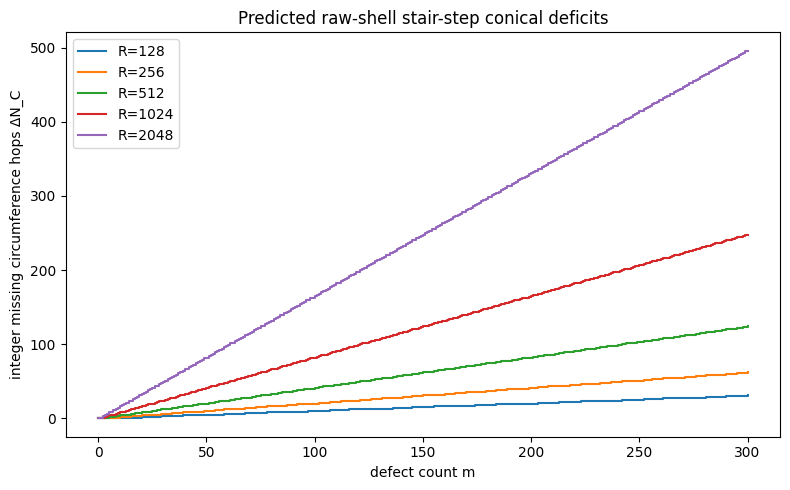

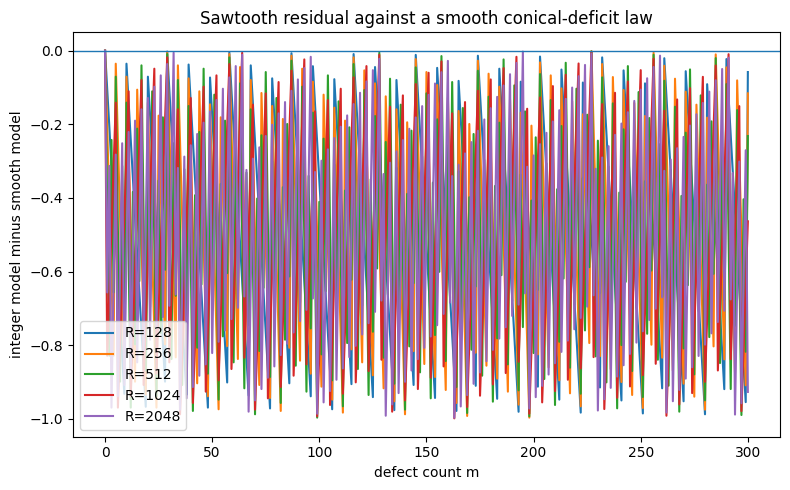

Saved figures: /mnt/data/deu_gr_exp01B_outputs/figures/predicted_raw_hex_staircase.png /mnt/data/deu_gr_exp01B_outputs/figures/staircase_sawtooth_residual.png


In [8]:

def make_staircase_sweep(R_values: Iterable[int], m_values: Iterable[int], *, kappa: float = KAPPA_HEX, mode: RoundingMode = 'floor', phase: float = 0.0) -> pd.DataFrame:
    rows = []
    for R in R_values:
        for m in m_values:
            d = integer_deficit_hops(R, m, kappa=kappa, mode=mode, phase=phase)
            rows.append({
                'R': R,
                'm': m,
                'Delta_NC': d,
                'N_C_flat': flat_hex_shell_size(R),
                'N_C_defect': flat_hex_shell_size(R) - d,
                'Delta_theta_raw': d / R if R else np.nan,
                'G_hat_hex': d / (24*m*R) if m and R else np.nan,
                'G_hat_cont': d / (8*math.pi*m*R) if m and R else np.nan,
                'smooth_expectation_hex': KAPPA_HEX*m*R,
            })
    return pd.DataFrame(rows)

m_values = np.arange(0, 301)
plot_radii = [128, 256, 512, 1024, 2048]
stair = make_staircase_sweep(plot_radii, m_values, kappa=KAPPA_HEX, mode='floor')
stair.to_csv(OUT / 'predicted_raw_hex_staircase_sweep.csv', index=False)

plt.figure(figsize=(8,5))
for R in plot_radii:
    sub = stair[stair['R'] == R]
    plt.step(sub['m'], sub['Delta_NC'], where='post', label=f'R={R}')
plt.xlabel('defect count m')
plt.ylabel('integer missing circumference hops ΔN_C')
plt.title('Predicted raw-shell stair-step conical deficits')
plt.legend()
plt.tight_layout()
fig1 = FIG / 'predicted_raw_hex_staircase.png'
plt.savefig(fig1, dpi=160)
plt.show()

plt.figure(figsize=(8,5))
for R in plot_radii:
    sub = stair[stair['R'] == R]
    plt.plot(sub['m'], sub['Delta_NC'] - sub['smooth_expectation_hex'], label=f'R={R}')
plt.axhline(0, linewidth=1)
plt.xlabel('defect count m')
plt.ylabel('integer model minus smooth model')
plt.title('Sawtooth residual against a smooth conical-deficit law')
plt.legend()
plt.tight_layout()
fig2 = FIG / 'staircase_sawtooth_residual.png'
plt.savefig(fig2, dpi=160)
plt.show()

print('Saved figures:', fig1, fig2)



## 8. Real DEU export schema

The real engine needs to export only one row per `(seed, cap, m, R, metric)` measurement. The same table can be produced for unweighted and refinement-weighted spatial metrics.


In [9]:

real_schema = pd.DataFrame([
    {'column':'experiment_id', 'required':True, 'description':'run label, e.g. exp01B_cap512_seed101'},
    {'column':'seed', 'required':True, 'description':'random seed'},
    {'column':'cap', 'required':True, 'description':'scheduler cap used by the triangular foam engine'},
    {'column':'target_basin_splits', 'required':True, 'description':'number of split events requested'},
    {'column':'epoch', 'required':False, 'description':'epoch at which spatial shell was measured'},
    {'column':'m', 'required':True, 'description':'integer count of persistent S-G defects injected/maintained'},
    {'column':'defect_id', 'required':False, 'description':'center defect/node/cluster identifier'},
    {'column':'R', 'required':True, 'description':'graph radius or weighted-radius bin center'},
    {'column':'metric', 'required':True, 'description':'unweighted_dual, refinement_weighted, registry_weighted, etc.'},
    {'column':'N_C_flat', 'required':True, 'description':'circumference shell count in matched m=0 control'},
    {'column':'N_C_defect', 'required':True, 'description':'circumference shell count around defect in m>0 run'},
    {'column':'Phi_rest', 'required':False, 'description':'stationary probe internal update fraction at same R, for lapse Ω = 1 - Φ_rest'},
    {'column':'Phi_moving', 'required':False, 'description':'moving probe internal update fraction at same R'},
    {'column':'v_global', 'required':False, 'description':'lateral split fraction relative to the external frontier clock'},
    {'column':'notes', 'required':False, 'description':'implementation details or warnings'},
])
real_schema.to_csv(OUT / 'real_deu_export_schema.csv', index=False)
display(real_schema)

# Template rows to make local engine export easy.
template_rows = []
for cap in [256, 512]:
    for seed in [101, 202]:
        for m in [0, 1, 2, 5, 10, 20, 50, 100]:
            for R in [128, 256, 512, 1024]:
                template_rows.append({
                    'experiment_id': f'exp01B_cap{cap}_seed{seed}',
                    'seed': seed,
                    'cap': cap,
                    'target_basin_splits': 10000,
                    'epoch': '',
                    'm': m,
                    'defect_id': '',
                    'R': R,
                    'metric': 'refinement_weighted',
                    'N_C_flat': '',
                    'N_C_defect': '',
                    'Phi_rest': '',
                    'Phi_moving': '',
                    'v_global': '',
                    'notes': '',
                })
real_template = pd.DataFrame(template_rows)
real_template.to_csv(OUT / 'real_deu_measurement_template.csv', index=False)
print('Wrote template rows:', len(real_template))


,column,required,description
0,experiment_id,True,"run label, e.g. exp01B_cap512_seed101"
1,seed,True,random seed
2,cap,True,scheduler cap used by the triangular foam engine
3,target_basin_splits,True,number of split events requested
4,epoch,False,epoch at which spatial shell was measured
5,m,True,integer count of persistent S-G defects inject...
6,defect_id,False,center defect/node/cluster identifier
7,R,True,graph radius or weighted-radius bin center
8,metric,True,"unweighted_dual, refinement_weighted, registry..."
9,N_C_flat,True,circumference shell count in matched m=0 control


Wrote template rows: 128



## 9. Analysis function for real DEU exports

Once the native engine exports the template columns, drop the CSV path into `analyze_real_deu_export(...)`. The function computes integer deficits, effective \(G\), residuals against the smooth model, and the unified lapse/motion residual when clock columns are available.


In [10]:

def analyze_real_deu_export(df: pd.DataFrame, *, normalization: Literal['hex','continuum']='hex') -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    required = {'m', 'R', 'N_C_flat', 'N_C_defect'}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    for c in ['m', 'R', 'N_C_flat', 'N_C_defect']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['Delta_NC'] = df['N_C_flat'] - df['N_C_defect']
    df['Delta_NC_is_integer'] = np.isclose(df['Delta_NC'], np.round(df['Delta_NC']), atol=1e-9)
    df['Delta_NC_round'] = np.round(df['Delta_NC']).astype('Int64')
    if normalization == 'hex':
        df['G_hat'] = np.where((df['m'] > 0) & (df['R'] > 0), df['Delta_NC'] / (24 * df['m'] * df['R']), np.nan)
        df['smooth_expected_Delta_NC'] = KAPPA_HEX * df['m'] * df['R']
    else:
        df['G_hat'] = np.where((df['m'] > 0) & (df['R'] > 0), df['Delta_NC'] / (8 * math.pi * df['m'] * df['R']), np.nan)
        df['smooth_expected_Delta_NC'] = KAPPA_CONT * df['m'] * df['R']
    df['smooth_residual'] = df['Delta_NC'] - df['smooth_expected_Delta_NC']
    # Unified bandwidth-law residual if clock columns are present.
    if {'Phi_rest', 'Phi_moving', 'v_global'}.issubset(df.columns):
        for c in ['Phi_rest', 'Phi_moving', 'v_global']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df['Omega_from_rest'] = 1 - df['Phi_rest']
        df['bandwidth_residual'] = df['Phi_moving']**2 + df['v_global']**2 - (1 - df['Omega_from_rest'])**2
    group_cols = [c for c in ['cap', 'metric', 'R'] if c in df.columns]
    if group_cols:
        summary = df[df['m'] > 0].groupby(group_cols, dropna=False).agg(
            n=('Delta_NC', 'size'),
            integer_pass_rate=('Delta_NC_is_integer', 'mean'),
            G_hat_median=('G_hat', 'median'),
            G_hat_mean=('G_hat', 'mean'),
            G_hat_std=('G_hat', 'std'),
            abs_smooth_resid_median=('smooth_residual', lambda s: float(np.nanmedian(np.abs(s)))),
        ).reset_index()
    else:
        summary = pd.DataFrame()
    return df, summary

# Demo by analyzing the synthetic staircase as though it came from the engine.
synthetic_as_export = stair.rename(columns={'N_C_defect':'N_C_defect'})
synthetic_as_export['cap'] = 512
synthetic_as_export['metric'] = 'synthetic_raw_hex'
synthetic_as_export['seed'] = 0
real_like, real_like_summary = analyze_real_deu_export(synthetic_as_export, normalization='hex')
real_like.to_csv(OUT / 'analysis_demo_synthetic_as_real.csv', index=False)
real_like_summary.to_csv(OUT / 'analysis_demo_synthetic_as_real_summary.csv', index=False)
display(real_like_summary.head(10))


,cap,metric,R,n,integer_pass_rate,G_hat_median,G_hat_mean,G_hat_std,abs_smooth_resid_median
0,512,synthetic_raw_hex,128,300,1.0,0.000033,0.000031,5.964380e-06,0.494829
1,512,synthetic_raw_hex,256,300,1.0,0.000033,0.000032,4.175381e-06,0.491923
2,512,synthetic_raw_hex,512,300,1.0,0.000033,0.000033,3.006601e-06,0.497440
3,512,synthetic_raw_hex,1024,300,1.0,0.000034,0.000033,2.188680e-06,0.501971
4,512,synthetic_raw_hex,2048,300,1.0,0.000034,0.000033,9.289395e-07,0.503942



## 10. Recommended native-engine runs

The old SR audit was cap-sensitive. The manuscript identifies cap-balanced windows as the place where interval-level \(2+1\)D Lorentzian behavior appears, while observer clocks were not cleanly recovered. Therefore the first gravity run should not search all caps blindly; it should hit the cap-balanced shoulder first and only then sweep controls.


In [11]:

recommended_runs = []
for cap, gap_hint in [(256, 'gap 4–16 and 4–12 were strong in local scaling'), (512, 'gap 4–24 was strongest in the SR fingerprint manuscript')]:
    for target in [10000, 20000]:
        recommended_runs.append({
            'priority': 'primary' if cap == 512 and target == 10000 else 'secondary',
            'cap': cap,
            'target_basin_splits': target,
            'seeds': '101,202,303,404',
            'm_sweep': '0,1,2,3,5,8,13,21,34,55,89,144,233',
            'R_shells': '128,256,512,1024,2048',
            'metrics': 'unweighted_dual + refinement_weighted',
            'gap_hint_from_SR_audit': gap_hint,
            'measurement': 'N_C_flat, N_C_defect; optional Phi_rest/Phi_moving/v_global probes',
        })
recommended_runs = pd.DataFrame(recommended_runs)
recommended_runs.to_csv(OUT / 'recommended_native_engine_runs.csv', index=False)
display(recommended_runs)


,priority,cap,target_basin_splits,seeds,m_sweep,R_shells,metrics,gap_hint_from_SR_audit,measurement
0,secondary,256,10000,"101,202,303,404","0,1,2,3,5,8,13,21,34,55,89,144,233","128,256,512,1024,2048",unweighted_dual + refinement_weighted,gap 4–16 and 4–12 were strong in local scaling,"N_C_flat, N_C_defect; optional Phi_rest/Phi_mo..."
1,secondary,256,20000,"101,202,303,404","0,1,2,3,5,8,13,21,34,55,89,144,233","128,256,512,1024,2048",unweighted_dual + refinement_weighted,gap 4–16 and 4–12 were strong in local scaling,"N_C_flat, N_C_defect; optional Phi_rest/Phi_mo..."
2,primary,512,10000,"101,202,303,404","0,1,2,3,5,8,13,21,34,55,89,144,233","128,256,512,1024,2048",unweighted_dual + refinement_weighted,gap 4–24 was strongest in the SR fingerprint m...,"N_C_flat, N_C_defect; optional Phi_rest/Phi_mo..."
3,secondary,512,20000,"101,202,303,404","0,1,2,3,5,8,13,21,34,55,89,144,233","128,256,512,1024,2048",unweighted_dual + refinement_weighted,gap 4–24 was strongest in the SR fingerprint m...,"N_C_flat, N_C_defect; optional Phi_rest/Phi_mo..."



## 11. Drop-in adapter sketch for the real SR engine

When the missing `src/` files are present, the real attachment point is after a foam run returns the active spatial object. The exact attribute names are engine-specific, so this function is intentionally conservative and raises an actionable error if it cannot find an adjacency map.


In [12]:

def try_extract_adjacency_from_engine_object(obj):
    '''Best-effort adapter for the old SR engine's active spatial graph.

    Expected successful return: dict[node] -> iterable[node].
    Edit this function once the real engine object (`rg2`, `phase_rg2_cap512`, etc.) is available.
    '''
    # Common possibilities in graph engines.
    candidate_attrs = ['adj', 'adjacency', 'spatial_adj', 'dual_adj', 'active_dual_adj', 'G']
    for attr in candidate_attrs:
        if hasattr(obj, attr):
            val = getattr(obj, attr)
            # networkx-like graph
            if hasattr(val, 'adj'):
                return {u: list(val.adj[u]) for u in val.nodes()}
            # dict adjacency
            if isinstance(val, dict):
                return {u: list(vs) for u, vs in val.items()}
    # Method-based possibilities.
    for meth in ['get_spatial_adjacency', 'active_spatial_adjacency', 'dual_face_adjacency']:
        if hasattr(obj, meth):
            val = getattr(obj, meth)()
            if isinstance(val, dict):
                return {u: list(vs) for u, vs in val.items()}
    raise TypeError(
        'Could not find a spatial adjacency map on this object. '
        'Please expose one of: adj, adjacency, spatial_adj, dual_adj, active_dual_adj, G, '
        'or implement get_spatial_adjacency().'
    )

adapter_notes = {
    'attachment_point': 'after run_foam_sr_sample(...) or equivalent returns rg2/active graph',
    'needed_real_engine_export': str(OUT / 'real_deu_measurement_template.csv'),
    'next_edit': 'map rg2 active faces or vertices to adjacency and choose defect center/cluster id',
}
(OUT / 'adapter_notes.json').write_text(json.dumps(adapter_notes, indent=2), encoding='utf-8')
print(json.dumps(adapter_notes, indent=2))


{
  "attachment_point": "after run_foam_sr_sample(...) or equivalent returns rg2/active graph",
  "needed_real_engine_export": "/mnt/data/deu_gr_exp01B_outputs/real_deu_measurement_template.csv",
  "next_edit": "map rg2 active faces or vertices to adjacency and choose defect center/cluster id"
}



## 12. Summary of this run

- The uploaded SR notebook was inspected.
- The old engine dependencies were audited.
- A real axial hex disk verified that the generic shell counter returns \(6R\).
- A synthetic conical shell graph verified that integer circumference deficits are recovered exactly.
- A real-engine export schema and analysis function were written.

The next non-synthetic test requires the missing `src/` engine files, especially the file that constructs the active triangular foam and exposes the active spatial graph.


In [13]:

summary = {
    'sr_notebook': str(SR_NOTEBOOK),
    'sr_notebook_exists': SR_NOTEBOOK.exists(),
    'missing_dependencies': missing,
    'flat_hex_max_shell_error': int(flat_counts['error'].abs().max()),
    'synthetic_cone_max_deficit_error': int(cone_counts['error'].abs().max()),
    'G_DEU': G_DEU,
    'KAPPA_CONT_8piG': KAPPA_CONT,
    'KAPPA_HEX_24G': KAPPA_HEX,
    'outputs_dir': str(OUT),
}
(OUT / 'run_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))


{
  "sr_notebook": "/mnt/data/DEU_SR_Fingerprint_Audit.ipynb",
  "sr_notebook_exists": true,
  "missing_dependencies": [
    "src/deu_exp456_minimal.py",
    "src/deu_exp456_overflow_patch.py",
    "src/deu_sr_fingerprint.py"
  ],
  "flat_hex_max_shell_error": 0,
  "synthetic_cone_max_deficit_error": 0,
  "G_DEU": 3.37e-05,
  "KAPPA_CONT_8piG": 0.0008469733794078082,
  "KAPPA_HEX_24G": 0.0008087999999999999,
  "outputs_dir": "/mnt/data/deu_gr_exp01B_outputs"
}
